# $\text{AR}(1)$ with Offset

$\text{AR}(1)$ with a constant offset is defined by,

$
\begin{equation}
X_t = \varphi X_{t-1} + \mu^* + \sigma \varepsilon_t
\end{equation}
\tag{1}
$

where, $\varepsilon \sim \text{Normal}(0,1)$

The stationarity requires $\lvert \varphi \rvert < 1$. The stationary mean and variance are given by,

$
\begin{align}
&\lim_{t \to \infty} \text{E}(X_t) = \frac{\mu^*}{1 - \varphi} \\
&\lim_{t \to \infty} \text{Var}(X_t) = \frac{\sigma^2}{1 - \varphi^2}
\end{align}
\tag{2}
$

It follows that $X_t$ has distribution,

$
\begin{align}
X_t \sim \text{Normal}\left(  \frac{\mu}{1 - \varphi} ,  \frac{\sigma^2}{1 - \varphi^2} \right)
\end{align}
\tag{3}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import stack, fcurve, PlotType, curve
from lib.data import arima, stats
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
σ = 1.0
nsample = 1000

def cumu_mean_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Mean to $t\\rightarrow\\infty$ Limit:  $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_mean = stats.compute_cumu_mean(t, ar)
    _, ar_mean = arima.compute_ar1_offset_mean(φ=φ, μ=μ, npts=len(t))
    fcurve(data=cumu_mean, func=ar_mean, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", r"$\mu_t\rightarrow \frac{\mu^*}{1 - \varphi}$"], title=title)
    
def cumu_sd_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Standard Deviation to $t\\rightarrow\\infty$ Limit: $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_sd = stats.compute_cumu_sd(t, ar)
    _, ar_sd = arima.compute_ar1_offset_sd(npts=len(t), φ=φ, σ=σ)
    fcurve(data=cumu_sd, func=ar_sd, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", r"$\sigma_t\rightarrow\sqrt{\frac{\sigma^2}{1-\varphi^2}}$"], title=title)
        
def comparison_plot_μ(μ_vals, ylim, title, *params):
    labels = [r"$μ^*=$" + f"{val}" for val in μ_vals]
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)
    
def comparison_plot_φ(φ_vals, ylim, title, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)


## Simulation $\varphi$ Scan

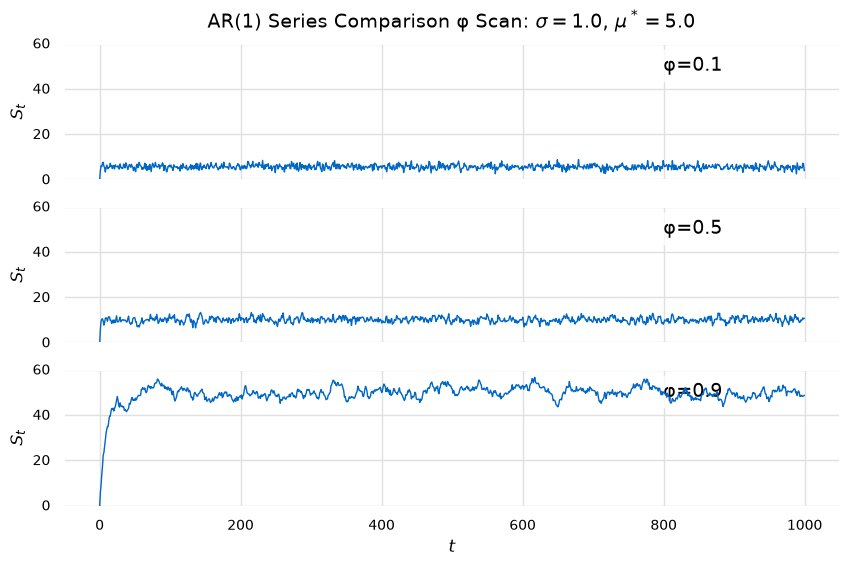

In [3]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: $σ={{{σ}}}$, $μ^*={{{μ}}}$"
φ_vals = [0.1, 0.5, 0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [0.0, 60.0], title, *params)

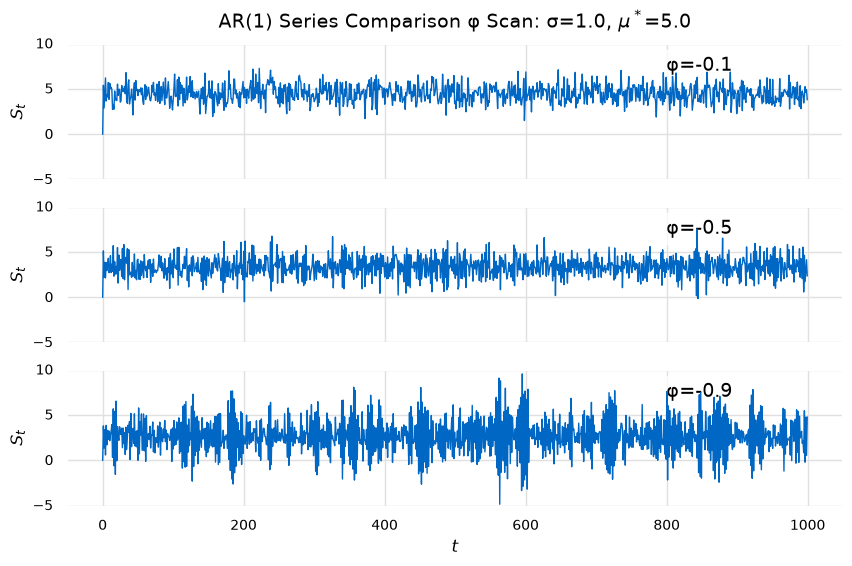

In [4]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: σ={σ}, " + r"$μ^*$=" + f"{μ}"
φ_vals = [-0.1, -0.5, -0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [-5.0, 10.0], title, *params)

## Simulation $\mu^*$ Scan

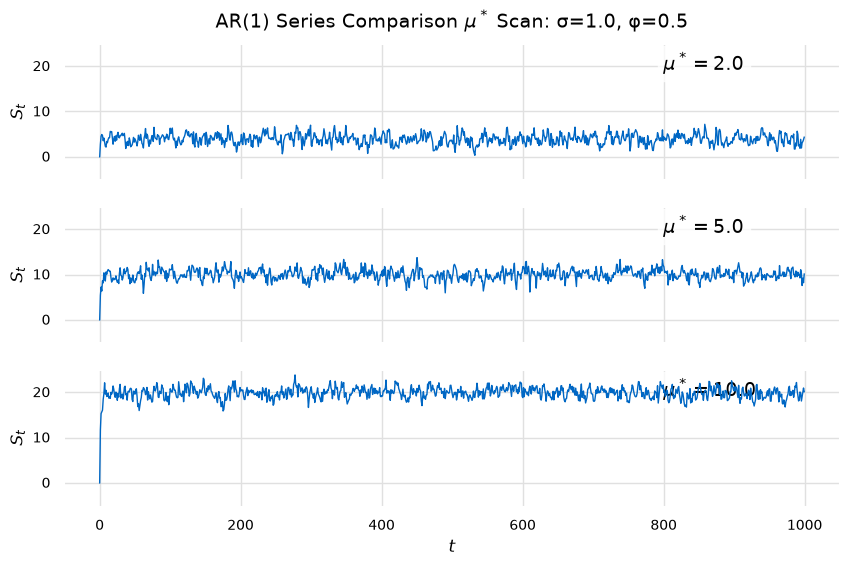

In [5]:
φ = 0.5
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [2.0, 5.0, 10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-5.0, 25.0], title, *params)

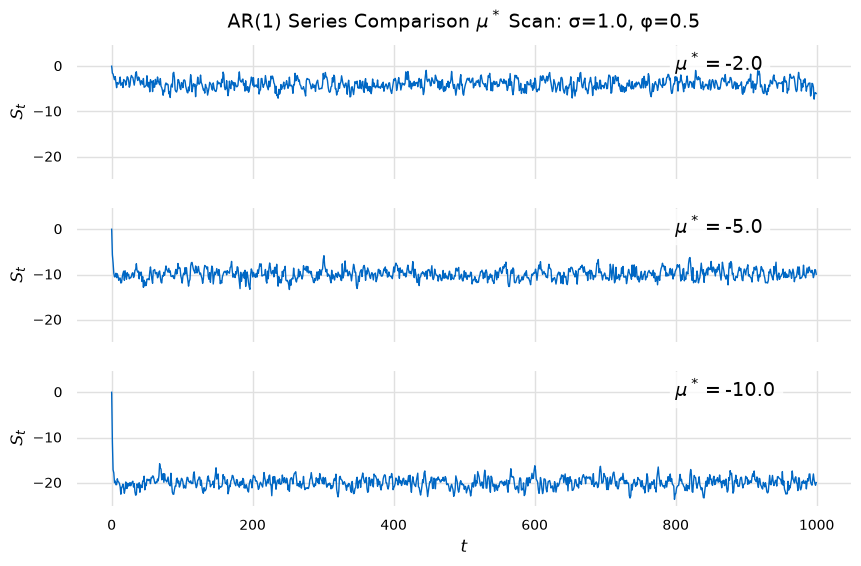

In [6]:
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [-2.0, -5.0, -10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-25.0, 5.0], title, *params)

## Mean

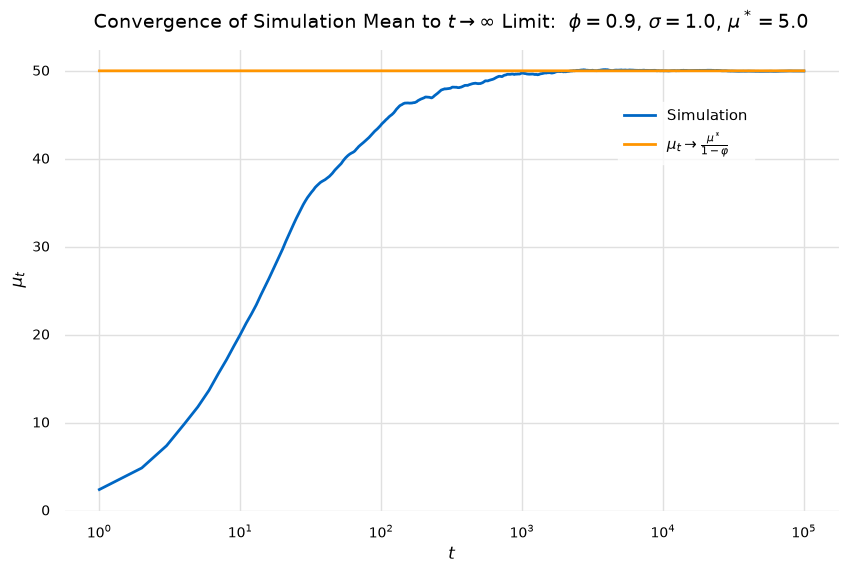

In [7]:
φ = 0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

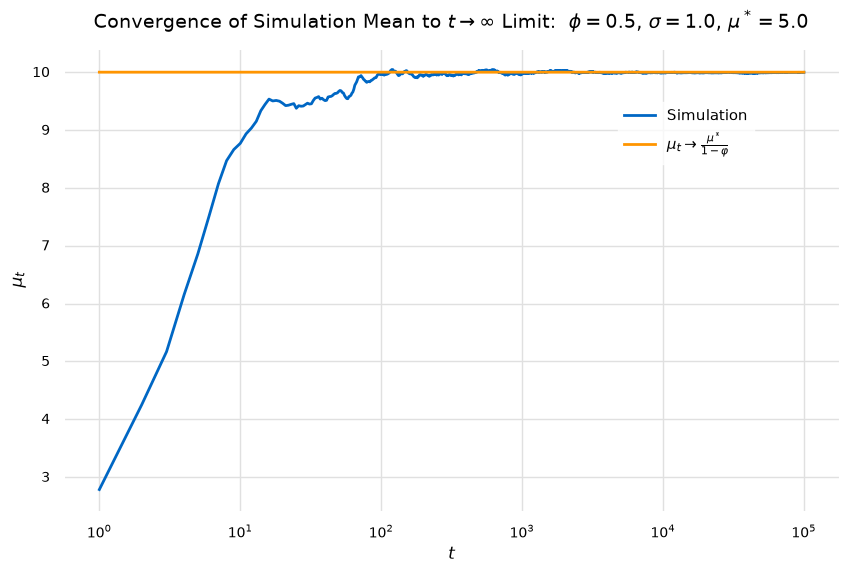

In [8]:
φ = 0.5
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

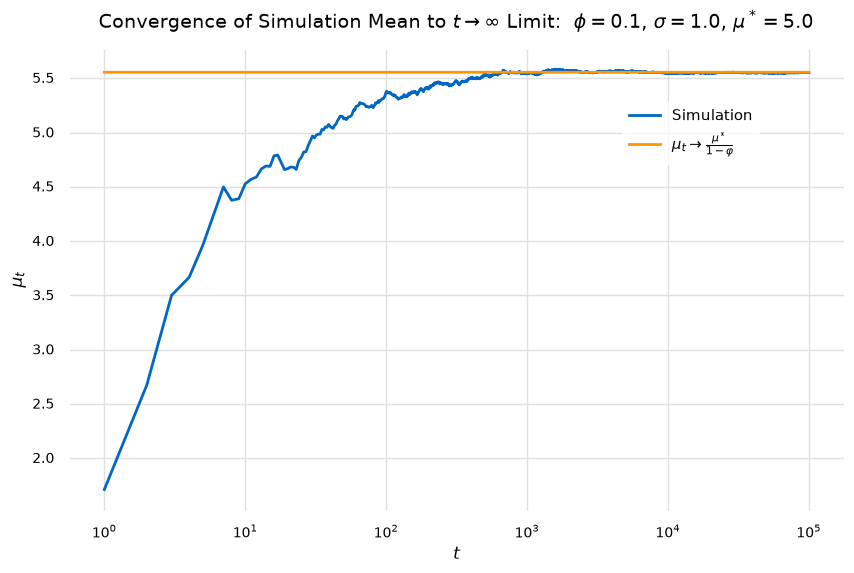

In [9]:
φ = 0.1
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

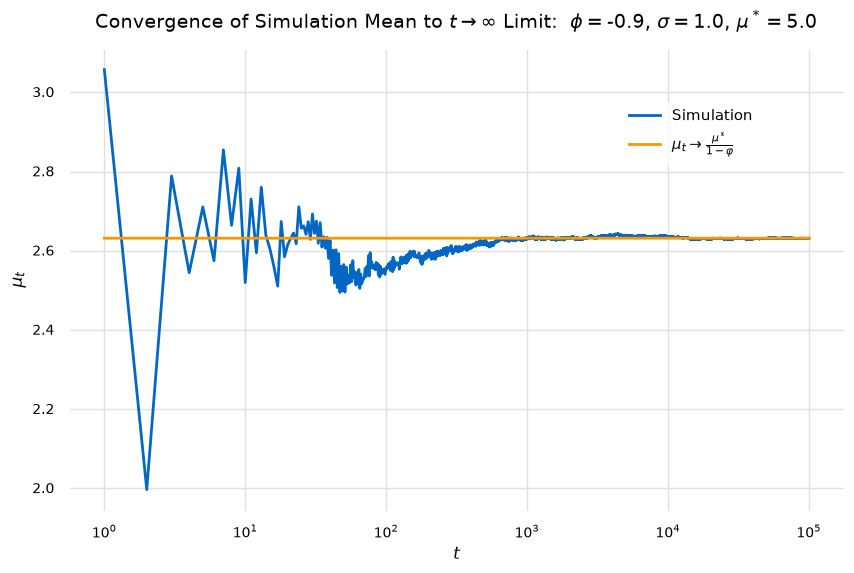

In [10]:
φ = -0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

## Standard Deviation

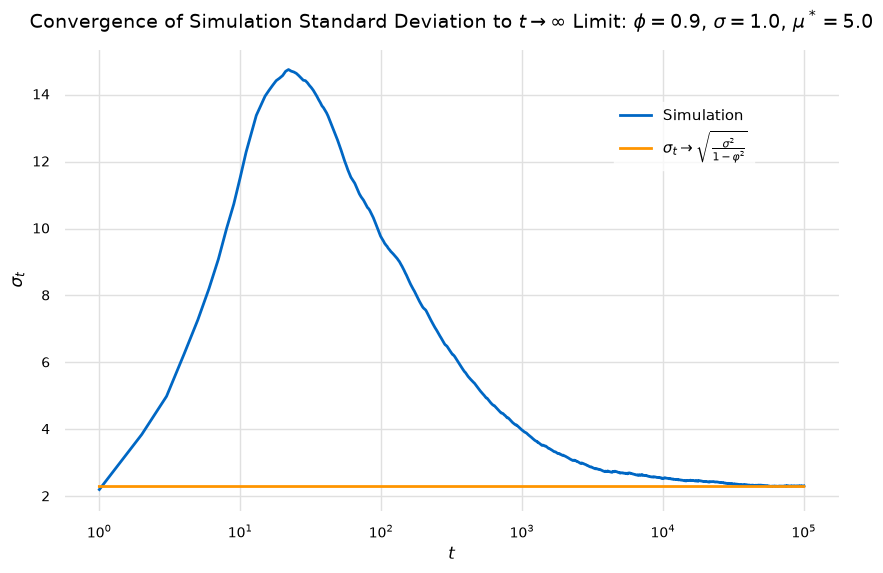

In [11]:
φ = 0.9
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

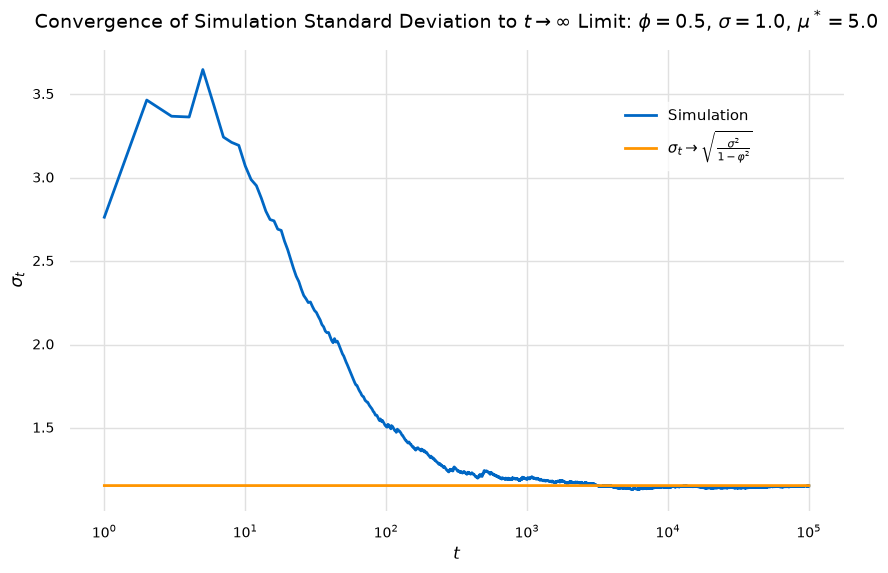

In [12]:
φ = 0.5
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

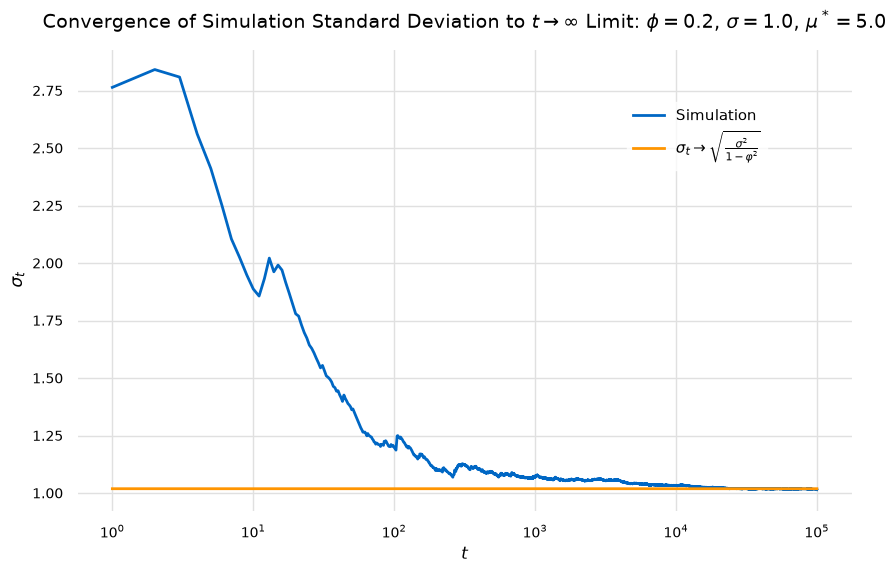

In [13]:
φ = 0.2
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

## Parameter Estimation

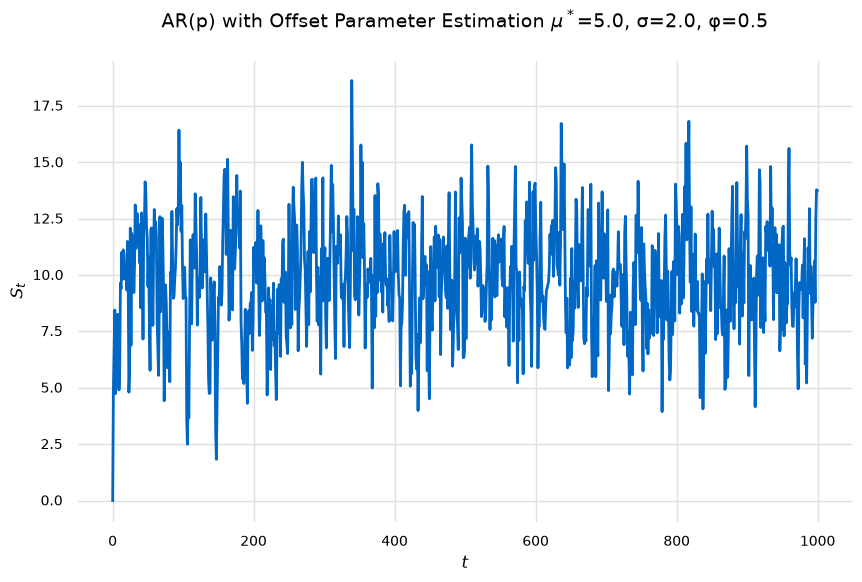

In [14]:
φ = 0.5
μ = 5.0
σ = 2.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [15]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2146.087
Date:                Sun, 30 Aug 2026   AIC                           4298.175
Time:                        11:23:14   BIC                           4312.898
Sample:                             0   HQIC                          4303.771
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8287      0.135     72.956      0.000       9.565      10.093
ar.L1          0.5196      0.027     19.219      0.000       0.467       0.573
sigma2         4.2801      0.188     22.810      0.000       3.912       4.648
===================================================================================
Ljung-Box (L1) (Q):                   0.91   Jarque-Bera (JB):                 3.16
Prob(Q):                              0.34   Prob(JB):                         0.21
Heteroskedasticity (H):               1.00   Skew:                            -0.12
Prob(H) (two-sided):                  1.00   Kurtosis:                         3.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 9.828690065728322,
      "err": 0.13472062826833717,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e15c75d8-1f8f-4eb5-98d3-5c1b5abc4695",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.5196009897295802,
         "err": 0.027035739428908814,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e15c75d8-1f8f-4eb5-98d3-5c1b5abc4695",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 4.280060758187319,
      "err": 0.18763629703037488,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
 

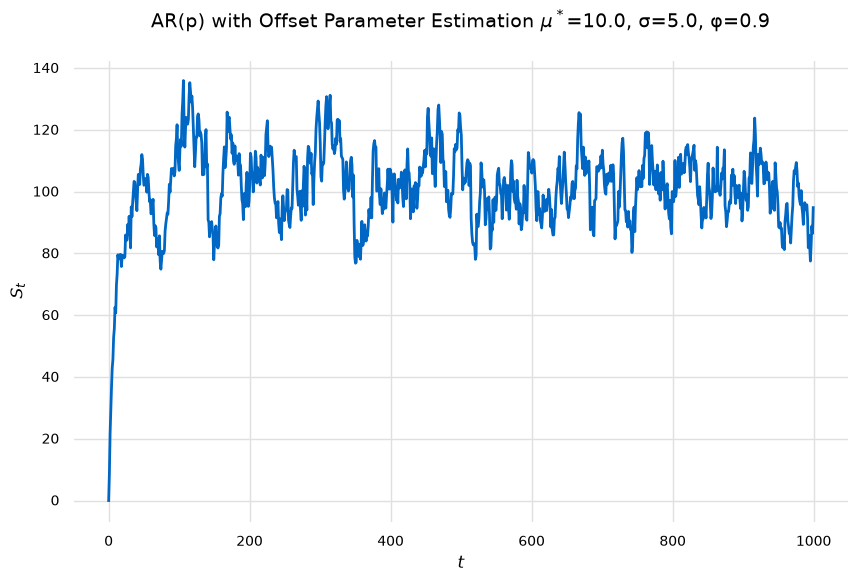

In [17]:
φ = 0.9
μ = 10.0
σ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [18]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3044.490
Date:                Sun, 30 Aug 2026   AIC                           6094.980
Time:                        11:23:14   BIC                           6109.703
Sample:                             0   HQIC                          6100.576
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.3254      2.983     33.301      0.000      93.480     105.171
ar.L1          0.9491      0.004    219.730      0.000       0.941       0.958
sigma2        25.7591      1.085     23.733      0.000      23.632      27.886
===================================================================================
Ljung-Box (L1) (Q):                   1.87   Jarque-Bera (JB):               101.97
Prob(Q):                              0.17   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                            -0.29
Prob(H) (two-sided):                  0.73   Kurtosis:                         4.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 99.32541339572705,
      "err": 2.982652768191521,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "102fd6e9-b07b-44f2-9ec6-c22e44fb7295",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.9491231112652712,
         "err": 0.0043195028364877985,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "102fd6e9-b07b-44f2-9ec6-c22e44fb7295",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.75909950038456,
      "err": 1.0853742667169788,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
   

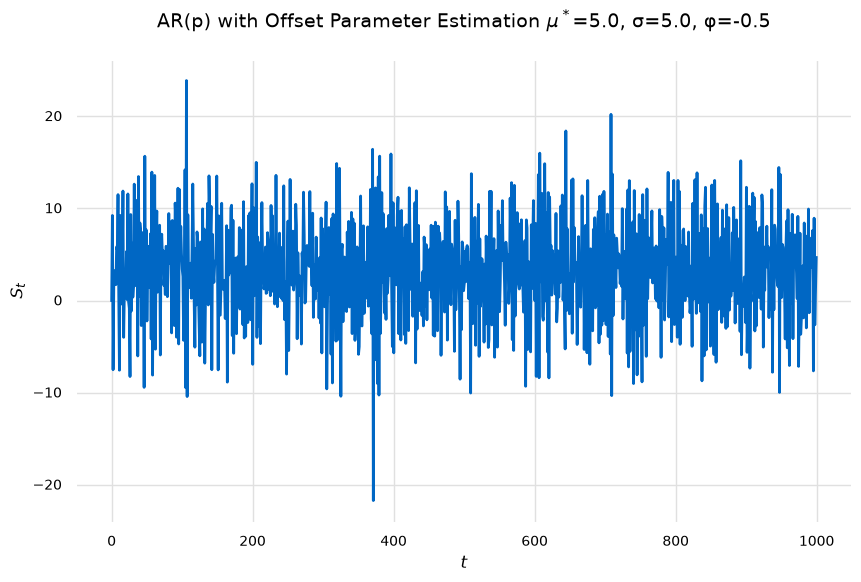

In [20]:
φ = -0.5
μ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [21]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3001.292
Date:                Sun, 30 Aug 2026   AIC                           6008.584
Time:                        11:23:14   BIC                           6023.308
Sample:                             0   HQIC                          6014.180
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2241      0.104     30.906      0.000       3.020       3.429
ar.L1         -0.4775      0.027    -17.775      0.000      -0.530      -0.425
sigma2        23.6756      1.073     22.074      0.000      21.573      25.778
===================================================================================
Ljung-Box (L1) (Q):                   0.76   Jarque-Bera (JB):                 0.78
Prob(Q):                              0.38   Prob(JB):                         0.68
Heteroskedasticity (H):               0.90   Skew:                            -0.06
Prob(H) (two-sided):                  0.35   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 3.224109974599033,
      "err": 0.10431868261353291,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "b75f3471-9e9c-47d7-9e44-d88c51aff8ec",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": -0.477473485880235,
         "err": 0.026862538480374475,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b75f3471-9e9c-47d7-9e44-d88c51aff8ec",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 23.67564869038688,
      "err": 1.0725804117105282,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
  